# Decision Trees and Ensemble Methods: Bank Note Authenticity

## Problem Statement
A central bank wants to automatically detect counterfeit bank notes using
physical measurements extracted from images. We will classify notes as
authentic or forged using decision trees and ensemble methods, then compare model performance across all approaches.

## Dataset
1,372 bank note records with the following features:
- `variance`  : Variance of wavelet transformed image
- `skewness`  : Skewness of wavelet transformed image
- `curtosis`  : Curtosis of wavelet transformed image
- `entropy`   : Entropy of the image
- `class`     : Target variable — 0 = authentic, 1 = forged

## Pipeline
1. Data Loading and EDA
2. Task 1 : Decision Tree (default)
3. Task 2 : Decision Tree (GridSearchCV tuned)
4. Task 3 : Random Forest (default)
5. Task 4 : Random Forest (GridSearchCV tuned)
6. Task 5 : AdaBoost (default)
7. Task 6 : AdaBoost (GridSearchCV tuned)
8. Task 7 : Model comparison and ROC curves

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                             f1_score, roc_auc_score, roc_curve,
                             ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [2]:
# 1. Data Loading
df = pd.read_csv('bank_note_authenticity.csv')

print(f'Shape: {df.shape}')
print(f'\nData types:\n{df.dtypes}')
print(f'\nMissing values: {df.isnull().sum().sum()}')
print(f'\nClass distribution:')
print(df['class'].value_counts())
print(f'\nForged note rate: {df["class"].mean():.1%}')
df.head()

Shape: (1372, 5)

Data types:
variance    float64
skewness    float64
curtosis    float64
entropy     float64
class         int64
dtype: object

Missing values: 0

Class distribution:
class
0    762
1    610
Name: count, dtype: int64

Forged note rate: 44.5%


,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


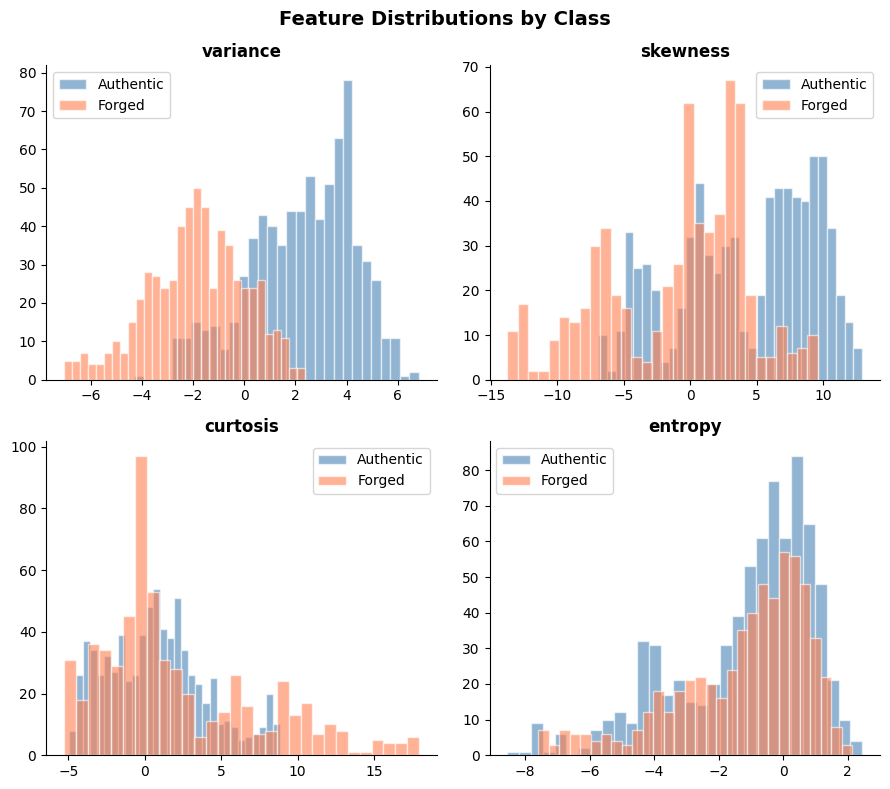

In [6]:
# EDA
fig, axes = plt.subplots(2, 2, figsize=(9, 8))
axes = axes.flatten()
features = ['variance', 'skewness', 'curtosis', 'entropy']

for i, col in enumerate(features):
    axes[i].hist(df[df['class']==0][col], bins=30, alpha=0.6,
                 color='steelblue', label='Authentic', edgecolor='white')
    axes[i].hist(df[df['class']==1][col], bins=30, alpha=0.6,
                 color='coral', label='Forged', edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend()

plt.suptitle('Feature Distributions by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



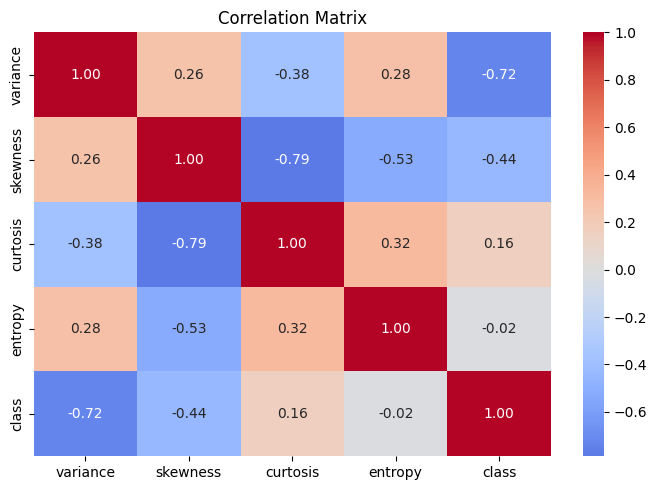

In [7]:
# Corelation heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [8]:
# Train/test split
X = df.drop('class', axis=1)
y = df['class']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=0)

print(f'X_train: {X_train.shape}, X_val: {X_val.shape}')
print(f'Train forged rate: {y_train.mean():.1%}')
print(f'Val   forged rate: {y_val.mean():.1%}')

X_train: (1097, 4), X_val: (275, 4)
Train forged rate: 44.8%
Val   forged rate: 42.9%


Leaves : 24
Depth  : 7


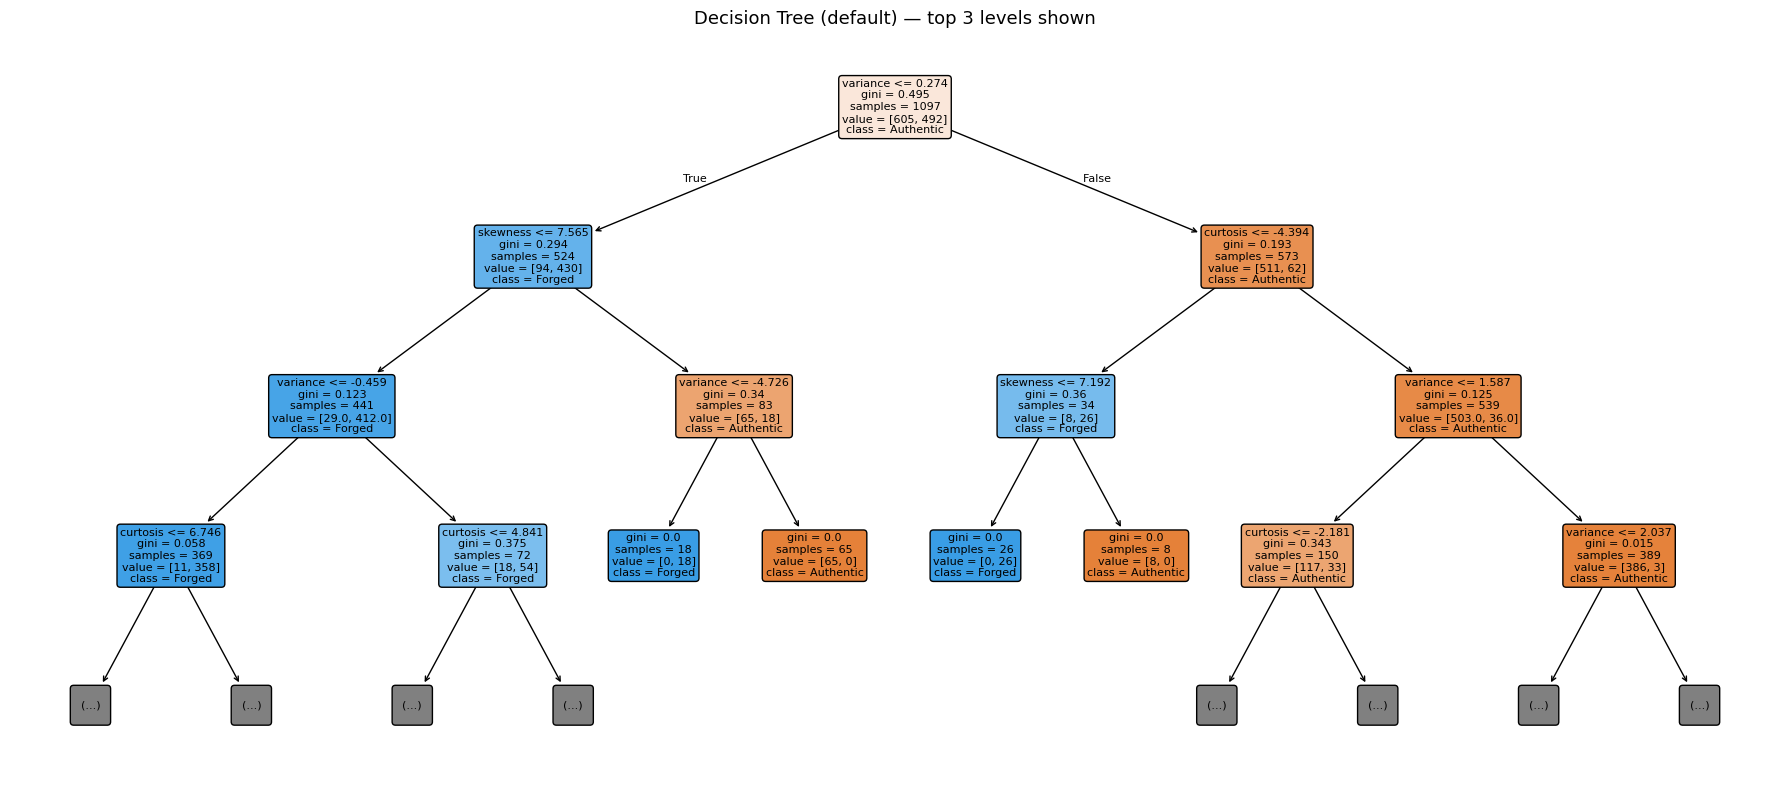

In [9]:
# ============================================================
# Task 1 : Decision Tree (default)
# ============================================================

tree_model_1 = DecisionTreeClassifier(random_state=0)
tree_model_1.fit(X_train, y_train)

# Tree structure
print(f'Leaves : {tree_model_1.get_n_leaves()}')
print(f'Depth  : {tree_model_1.get_depth()}')

# Visualise
plt.figure(figsize=(18, 8))
plot_tree(tree_model_1, feature_names=X.columns, class_names=['Authentic', 'Forged'],
          filled=True, rounded=True, fontsize=8, max_depth=3)
plt.title('Decision Tree (default) — top 3 levels shown', fontsize=13)
plt.tight_layout()
plt.show()



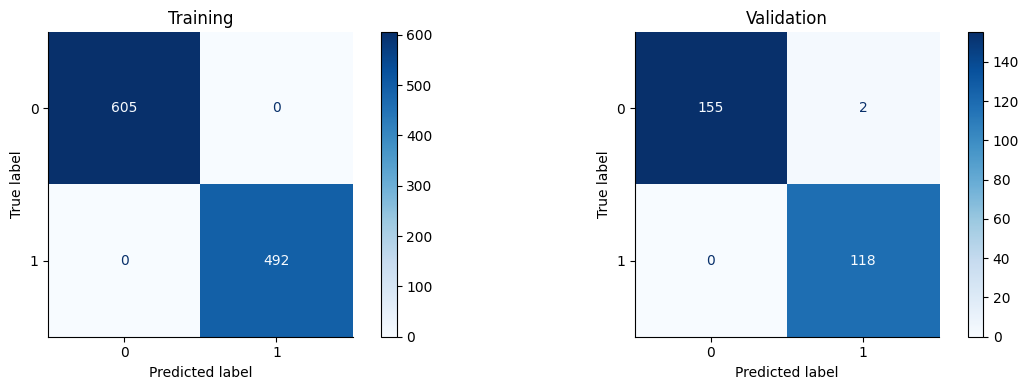

,Accuracy,Sensitivity
tree_model_1_train,1.000000,1.0
tree_model_1_val,0.992727,1.0


In [10]:
# Confusion matrices
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_estimator(tree_model_1, X_train, y_train,
                                      cmap='Blues', ax=ax[0])
ConfusionMatrixDisplay.from_estimator(tree_model_1, X_val, y_val,
                                      cmap='Blues', ax=ax[1])
ax[0].set_title('Training')
ax[1].set_title('Validation')
plt.tight_layout()
plt.show()

# Metrics
y_pred_1_train = tree_model_1.predict(X_train)
y_pred_1_val   = tree_model_1.predict(X_val)

tree_1_metrics = pd.DataFrame({
    'Accuracy'   : [accuracy_score(y_train, y_pred_1_train), accuracy_score(y_val, y_pred_1_val)],
    'Sensitivity': [recall_score(y_train, y_pred_1_train),   recall_score(y_val, y_pred_1_val)]
}, index=['tree_model_1_train', 'tree_model_1_val'])
tree_1_metrics

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best params : {'max_depth': 6, 'min_samples_leaf': 5}
Best CV recall : 0.9736
Leaves : 20
Depth  : 6


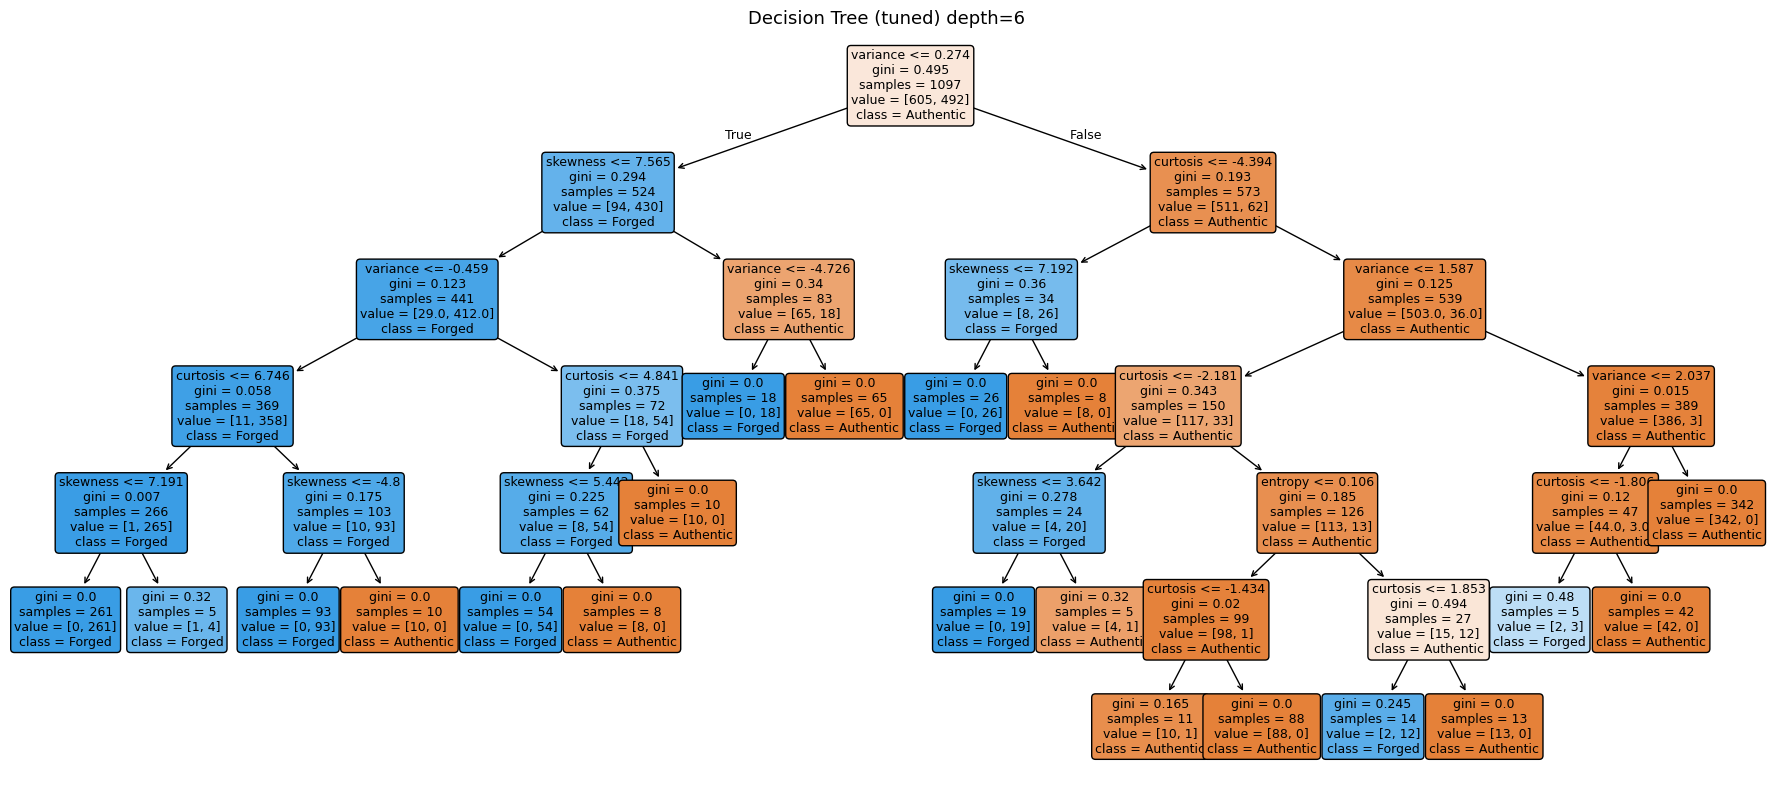

In [12]:
# ============================================================
# Task 2 — Decision Tree (GridSearchCV tuned)
# ============================================================

param_grid = {
    'max_depth'       : [2, 4, 6],
    'min_samples_leaf': [5, 10, 15]
}

tree_model_2 = GridSearchCV(
    DecisionTreeClassifier(random_state=0),
    param_grid,
    scoring='recall',
    cv=5,
    verbose=1
)
tree_model_2.fit(X_train, y_train)

print(f'Best params : {tree_model_2.best_params_}')
print(f'Best CV recall : {tree_model_2.best_score_:.4f}')
print(f'Leaves : {tree_model_2.best_estimator_.get_n_leaves()}')
print(f'Depth  : {tree_model_2.best_estimator_.get_depth()}')

# Visualise best tree
plt.figure(figsize=(18, 8))
plot_tree(tree_model_2.best_estimator_, feature_names=X.columns,
          class_names=['Authentic', 'Forged'], filled=True, rounded=True, fontsize=9)
plt.title(f'Decision Tree (tuned) depth={tree_model_2.best_estimator_.get_depth()}', fontsize=13)
plt.tight_layout()
plt.show()



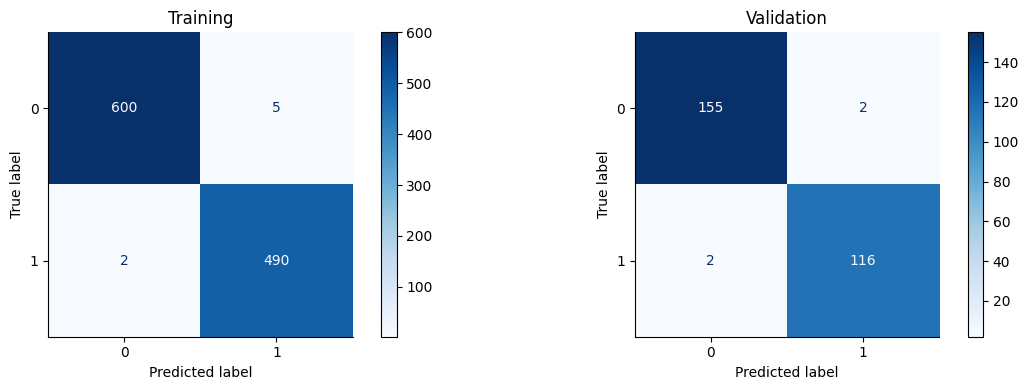

,Accuracy,Sensitivity
tree_model_2_train,0.993619,0.995935
tree_model_2_val,0.985455,0.983051


In [13]:
# Confusion matrices
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_estimator(tree_model_2.best_estimator_, X_train, y_train,
                                      cmap='Blues', ax=ax[0])
ConfusionMatrixDisplay.from_estimator(tree_model_2.best_estimator_, X_val, y_val,
                                      cmap='Blues', ax=ax[1])
ax[0].set_title('Training')
ax[1].set_title('Validation')
plt.tight_layout()
plt.show()

# Metrics
y_pred_2_train = tree_model_2.best_estimator_.predict(X_train)
y_pred_2_val   = tree_model_2.best_estimator_.predict(X_val)

tree_2_metrics = pd.DataFrame({
    'Accuracy'   : [accuracy_score(y_train, y_pred_2_train), accuracy_score(y_val, y_pred_2_val)],
    'Sensitivity': [recall_score(y_train, y_pred_2_train),   recall_score(y_val, y_pred_2_val)]
}, index=['tree_model_2_train', 'tree_model_2_val'])
tree_2_metrics

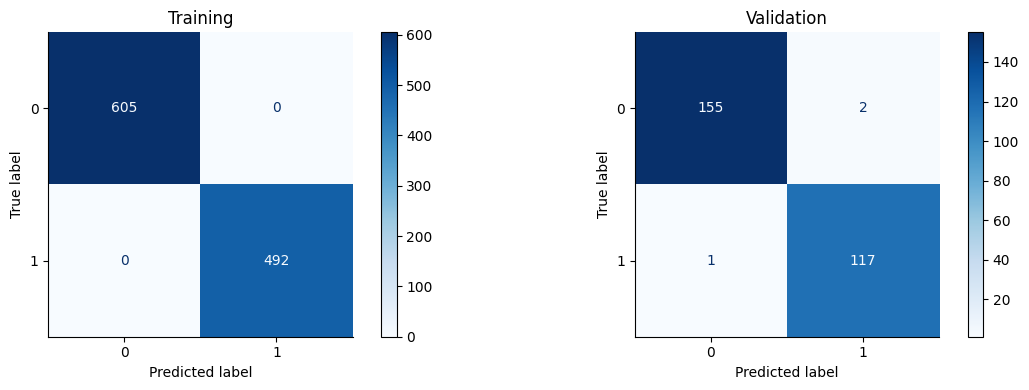

,Accuracy,Sensitivity
rf1_train,1.000000,1.000000
rf1_val,0.989091,0.991525


In [15]:
# ============================================================
# Task 3 : Random Forest (default)
# ============================================================

rf1 = RandomForestClassifier(random_state=0)
rf1.fit(X_train, y_train)

# Confusion matrices
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_estimator(rf1, X_train, y_train, cmap='Blues', ax=ax[0])
ConfusionMatrixDisplay.from_estimator(rf1, X_val, y_val, cmap='Blues', ax=ax[1])
ax[0].set_title('Training')
ax[1].set_title('Validation')
plt.tight_layout()
plt.show()

# Metrics
y_pred_rf1_train = rf1.predict(X_train)
y_pred_rf1_val   = rf1.predict(X_val)

rf1_metrics = pd.DataFrame({
    'Accuracy'   : [accuracy_score(y_train, y_pred_rf1_train), accuracy_score(y_val, y_pred_rf1_val)],
    'Sensitivity': [recall_score(y_train, y_pred_rf1_train),   recall_score(y_val, y_pred_rf1_val)]
}, index=['rf1_train', 'rf1_val'])
rf1_metrics

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params    : {'max_depth': 6, 'n_estimators': np.int64(50)}
Best CV F1     : 0.9889


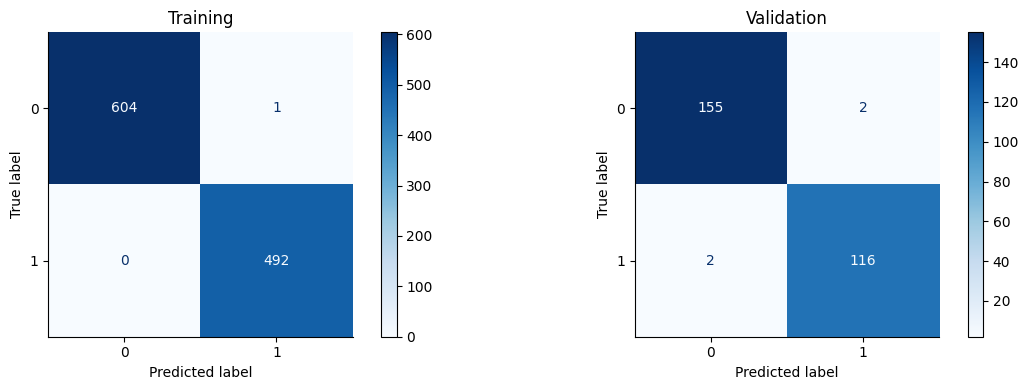

,Accuracy,Sensitivity
rf2_train,0.999088,1.000000
rf2_val,0.985455,0.983051


In [16]:
# ============================================================
# Task 4 : Random Forest (GridSearchCV tuned)
# ============================================================

param_grid = {
    'n_estimators': np.arange(25, 125, 25),
    'max_depth'   : [2, 4, 6]
}

rf2 = GridSearchCV(
    RandomForestClassifier(random_state=0),
    param_grid,
    scoring='f1',
    cv=5,
    verbose=1
)
rf2.fit(X_train, y_train)

print(f'Best params    : {rf2.best_params_}')
print(f'Best CV F1     : {rf2.best_score_:.4f}')

# Confusion matrices
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_estimator(rf2, X_train, y_train, cmap='Blues', ax=ax[0])
ConfusionMatrixDisplay.from_estimator(rf2, X_val, y_val, cmap='Blues', ax=ax[1])
ax[0].set_title('Training')
ax[1].set_title('Validation')
plt.tight_layout()
plt.show()

# Metrics
y_pred_rf2_train = rf2.predict(X_train)
y_pred_rf2_val   = rf2.predict(X_val)

rf2_metrics = pd.DataFrame({
    'Accuracy'   : [accuracy_score(y_train, y_pred_rf2_train), accuracy_score(y_val, y_pred_rf2_val)],
    'Sensitivity': [recall_score(y_train, y_pred_rf2_train),   recall_score(y_val, y_pred_rf2_val)]
}, index=['rf2_train', 'rf2_val'])
rf2_metrics

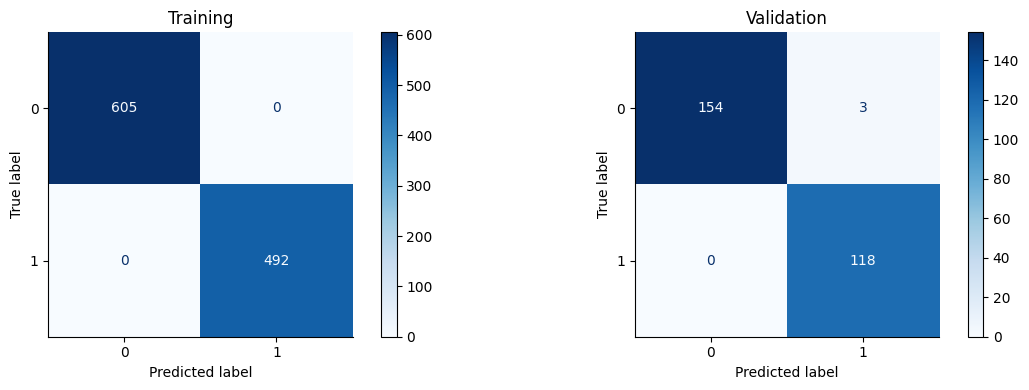

,Accuracy,Sensitivity
gbt1_train,1.000000,1.0
gbt1_val,0.989091,1.0


In [17]:
# ============================================================
# Task 5 : AdaBoost (default)
# ============================================================

gbt1 = AdaBoostClassifier(random_state=0, algorithm='SAMME')
gbt1.fit(X_train, y_train)

# Confusion matrices
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_estimator(gbt1, X_train, y_train, cmap='Blues', ax=ax[0])
ConfusionMatrixDisplay.from_estimator(gbt1, X_val, y_val, cmap='Blues', ax=ax[1])
ax[0].set_title('Training')
ax[1].set_title('Validation')
plt.tight_layout()
plt.show()

# Metrics
y_pred_gbt1_train = gbt1.predict(X_train)
y_pred_gbt1_val   = gbt1.predict(X_val)

gbt1_metrics = pd.DataFrame({
    'Accuracy'   : [accuracy_score(y_train, y_pred_gbt1_train), accuracy_score(y_val, y_pred_gbt1_val)],
    'Sensitivity': [recall_score(y_train, y_pred_gbt1_train),   recall_score(y_val, y_pred_gbt1_val)]
}, index=['gbt1_train', 'gbt1_val'])
gbt1_metrics

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best paras : {'learning_rate': 1, 'n_estimators': np.int64(100)}
Best CV F1  : 0.9929


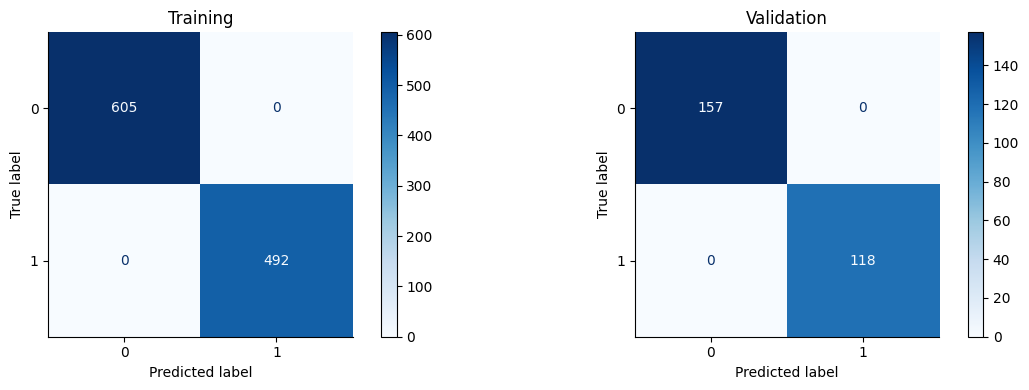

,Accuracy,Sensitivity
gbt2_train,1.0,1.0
gbt2_val,1.0,1.0


In [18]:
# ============================================================
# Task 6: AdaBoost (GridSearchCV tuned)
# ============================================================

param_grid = {
    'n_estimators' : np.arange(25, 125, 25),
    'learning_rate': [0.01, 0.1, 1]
}

gbt2 = GridSearchCV(
    AdaBoostClassifier(random_state=0, algorithm='SAMME'),
    param_grid,
    scoring='f1',
    cv=5,
    verbose=1
)
gbt2.fit(X_train, y_train)

print(f'Best paras : {gbt2.best_params_}')
print(f'Best CV F1  : {gbt2.best_score_:.4f}')

# Confusion matrices
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_estimator(gbt2, X_train, y_train, cmap='Blues', ax=ax[0])
ConfusionMatrixDisplay.from_estimator(gbt2, X_val, y_val, cmap='Blues', ax=ax[1])
ax[0].set_title('Training')
ax[1].set_title('Validation')
plt.tight_layout()
plt.show()

# Metrics
y_pred_gbt2_train = gbt2.predict(X_train)
y_pred_gbt2_val   = gbt2.predict(X_val)

gbt2_metrics = pd.DataFrame({
    'Accuracy'   : [accuracy_score(y_train, y_pred_gbt2_train), accuracy_score(y_val, y_pred_gbt2_val)],
    'Sensitivity': [recall_score(y_train, y_pred_gbt2_train),   recall_score(y_val, y_pred_gbt2_val)]
}, index=['gbt2_train', 'gbt2_val'])
gbt2_metrics

In [19]:
# ============================================================
# Task 7 : Model comparion + ROC curves
# ============================================================

models     = [tree_model_1, tree_model_2.best_estimator_, rf1, rf2.best_estimator_, gbt1, gbt2.best_estimator_]
modelnames = ['tree_model_1', 'tree_model_2', 'rf1', 'rf2', 'gbt1', 'gbt2']

rows = []
for name, model in zip(modelnames, models):
    tr_prob = model.predict_proba(X_train)[:, 1]
    va_prob = model.predict_proba(X_val)[:, 1]
    tr_pred = model.predict(X_train)
    va_pred = model.predict(X_val)
    rows.append({
        'Model'               : name,
        'Train Accuracy'      : accuracy_score(y_train, tr_pred),
        'Val Accuracy'        : accuracy_score(y_val, va_pred),
        'Train Sensitivity'   : recall_score(y_train, tr_pred),
        'Val Sensitivity'     : recall_score(y_val, va_pred),
        'Train Specificity'   : recall_score(y_train, tr_pred, pos_label=0),
        'Val Specificity'     : recall_score(y_val, va_pred, pos_label=0),
        'Train F1'            : f1_score(y_train, tr_pred),
        'Val F1'              : f1_score(y_val, va_pred),
        'Train AUC'           : roc_auc_score(y_train, tr_prob),
        'Val AUC'             : roc_auc_score(y_val, va_prob),
    })

modelcompare = pd.DataFrame(rows).set_index('Model').round(4)
modelcompare

,Train Accuracy,Val Accuracy,Train Sensitivity,Val Sensitivity,Train Specificity,Val Specificity,Train F1,Val F1,Train AUC,Val AUC
Model,,,,,,,,,,
tree_model_1,1.0000,0.9927,1.0000,1.0000,1.0000,0.9873,1.0000,0.9916,1.0000,0.9936
tree_model_2,0.9936,0.9855,0.9959,0.9831,0.9917,0.9873,0.9929,0.9831,0.9998,0.9929
rf1,1.0000,0.9891,1.0000,0.9915,1.0000,0.9873,1.0000,0.9873,1.0000,0.9998
rf2,0.9991,0.9855,1.0000,0.9831,0.9983,0.9873,0.9990,0.9831,1.0000,0.9996
gbt1,1.0000,0.9891,1.0000,1.0000,1.0000,0.9809,1.0000,0.9874,1.0000,0.9998
gbt2,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


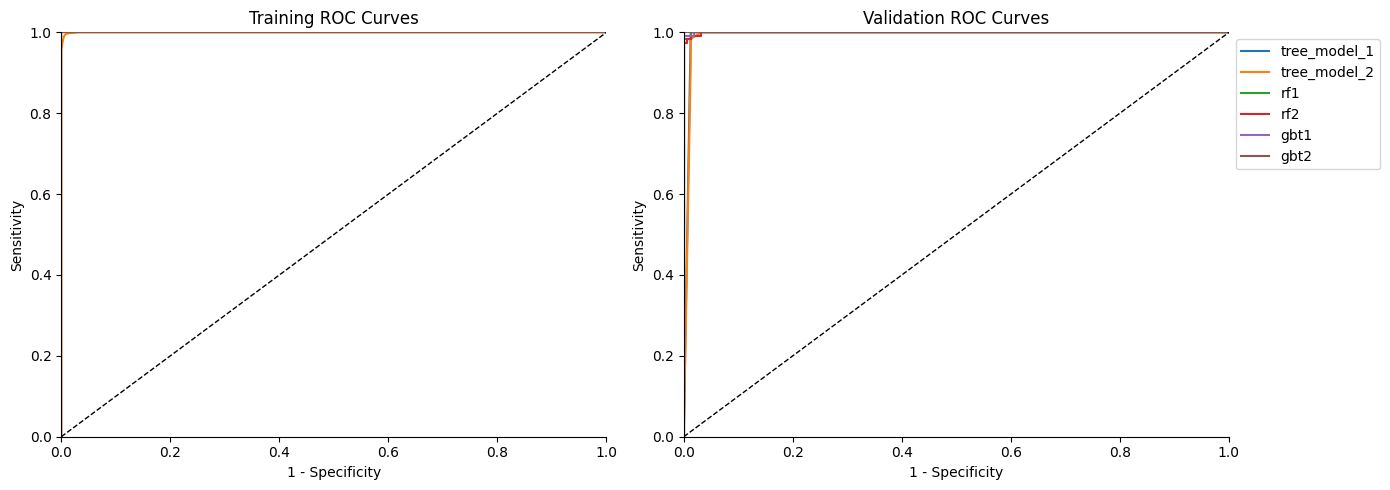

In [20]:
# Final ROC curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = sns.color_palette(n_colors=len(models))

train_probs = [m.predict_proba(X_train)[:, 1] for m in models]
val_probs   = [m.predict_proba(X_val)[:, 1]   for m in models]

for i, name in enumerate(modelnames):
    fpr_tr, tpr_tr, _ = roc_curve(y_train, train_probs[i])
    fpr_va, tpr_va, _ = roc_curve(y_val,   val_probs[i])
    axes[0].plot(fpr_tr, tpr_tr, color=colors[i])
    axes[1].plot(fpr_va, tpr_va, color=colors[i], label=name)

for ax, title in zip(axes, ['Training ROC Curves', 'Validation ROC Curves']):
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax.set_xlabel('1 - Specificity')
    ax.set_ylabel('Sensitivity')
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

axes[1].legend(bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

## Summary

### Dataset
1,372 bank notes, 4 wavelet image features, 44.5% forged. Well-balanced and
highly separable `variance` alone correlates -0.72 with the target.

### Key findings

| Model | Val Accuracy | Val Sensitivity | Val AUC |
|---|---|---|---|
| tree_model_1 (default) | 0.9927 | 1.0000 | 0.9936 |
| tree_model_2 (tuned)   | 0.9855 | 0.9831 | 0.9929 |
| rf1 (default)          | 0.9891 | 0.9915 | 0.9998 |
| rf2 (tuned)            | 0.9855 | 0.9831 | 0.9996 |
| gbt1 (default)         | 0.9891 | 1.0000 | 0.9998 |
| gbt2 (tuned)           | 1.0000 | 1.0000 | 1.0000 |

- Tuning hurt single decision trees and random forest here as the default
  models were alredy near-optimal on clean, separable data
- AdaBoost benefited most from tuning — learning_rate=1 with 100 estimators pushed it to perfect validation scores
- All models have near-identical ROC curves because variance and skewness
  provide very strong class separation

### Ensemble methods vs single tree

| Method | Idea | Strength |
|---|---|---|
| Decision Tree | One tree, greedy splits | Fast, interpretable |
| Random Forest | 100 trees on random data+feature subsets, majority vote | Reduces variance |
| AdaBoost | Sequetial trees, each focuses on prior mistakes | Reduces bias |